# 04 Baseline and Logistic Regression Modeling

## Loan Default Prediction and Credit Risk Scorecard

This notebook builds the first machine learning models for loan default prediction. It includes a naive baseline, standard logistic regression, class-weighted logistic regression, and regularized logistic regression.

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 100)

In [2]:
df = pd.read_csv("../data/processed/loan_modeling_dataset.csv")

df.shape

(1369566, 37)

In [3]:
df["default_flag"].value_counts(normalize=True).mul(100).round(2)

default_flag
0    78.77
1    21.23
Name: proportion, dtype: float64

In [4]:
target = "default_flag"

X = df.drop(columns=[target])
y = df[target]

X.shape, y.shape

((1369566, 36), (1369566,))

In [5]:
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print(numeric_features)

print("\nCategorical features:", len(categorical_features))
print(categorical_features)

Numeric features: 27
['loan_amnt', 'funded_amnt', 'term_months', 'int_rate', 'installment', 'grade_risk_numeric', 'emp_length_years', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies', 'issue_year', 'issue_month', 'credit_history_months', 'loan_income_ratio', 'installment_income_ratio', 'high_dti_flag', 'high_revol_util_flag', 'recent_inquiry_flag', 'long_term_flag']

Categorical features: 9
['grade', 'sub_grade', 'home_ownership', 'verification_status', 'purpose', 'application_type', 'income_band', 'dti_band', 'credit_history_band']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train default rate:", y_train.mean().round(4))
print("y_test default rate:", y_test.mean().round(4))

X_train: (1027174, 36)
X_test: (342392, 36)
y_train default rate: 0.2123
y_test default rate: 0.2124


In [7]:
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipeline, numeric_features),
        ("cat", categorical_pipeline, categorical_features)
    ]
)

In [8]:
def evaluate_classifier(model_name, y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    
    return {
        "model": model_name,
        "threshold": threshold,
        "roc_auc": roc_auc_score(y_true, y_prob),
        "pr_auc": average_precision_score(y_true, y_prob),
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1_score": f1_score(y_true, y_pred, zero_division=0)
    }

In [9]:
baseline_prob = np.repeat(y_train.mean(), len(y_test))

baseline_results = evaluate_classifier(
    "Naive Baseline",
    y_test,
    baseline_prob,
    threshold=0.5
)

baseline_results

{'model': 'Naive Baseline',
 'threshold': 0.5,
 'roc_auc': 0.5,
 'pr_auc': 0.21235017173298443,
 'accuracy': 0.7876498282670156,
 'precision': 0.0,
 'recall': 0.0,
 'f1_score': 0.0}

In [10]:
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        n_jobs=-1
    ))
])

logistic_model.fit(X_train, y_train)

logistic_probs = logistic_model.predict_proba(X_test)[:, 1]

logistic_results = evaluate_classifier(
    "Logistic Regression",
    y_test,
    logistic_probs,
    threshold=0.5
)

logistic_results

{'model': 'Logistic Regression',
 'threshold': 0.5,
 'roc_auc': 0.7161152845392028,
 'pr_auc': 0.39999144889021443,
 'accuracy': 0.7916248043178579,
 'precision': 0.559656351363198,
 'recall': 0.08780447549754494,
 'f1_score': 0.1517939938654683}

In [11]:
weighted_logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="lbfgs",
        class_weight="balanced",
        n_jobs=-1
    ))
])

weighted_logistic_model.fit(X_train, y_train)

weighted_logistic_probs = weighted_logistic_model.predict_proba(X_test)[:, 1]

weighted_logistic_results = evaluate_classifier(
    "Weighted Logistic Regression",
    y_test,
    weighted_logistic_probs,
    threshold=0.5
)

weighted_logistic_results

{'model': 'Weighted Logistic Regression',
 'threshold': 0.5,
 'roc_auc': 0.7160715143150036,
 'pr_auc': 0.39916396495914314,
 'accuracy': 0.6447405313208252,
 'precision': 0.33443639144351733,
 'recall': 0.6797144704086264,
 'f1_score': 0.4482986964685819}

In [12]:
regularized_logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=1000,
        solver="liblinear",
        penalty="l2",
        C=0.5,
        class_weight="balanced"
    ))
])

regularized_logistic_model.fit(X_train, y_train)

regularized_logistic_probs = regularized_logistic_model.predict_proba(X_test)[:, 1]

regularized_logistic_results = evaluate_classifier(
    "Regularized Weighted Logistic Regression",
    y_test,
    regularized_logistic_probs,
    threshold=0.5
)

regularized_logistic_results

{'model': 'Regularized Weighted Logistic Regression',
 'threshold': 0.5,
 'roc_auc': 0.7160928541391121,
 'pr_auc': 0.3991799227860052,
 'accuracy': 0.6445652935816257,
 'precision': 0.3343342734054281,
 'recall': 0.6799207779168444,
 'f1_score': 0.4482517862971963}

In [13]:
model_results = pd.DataFrame([
    baseline_results,
    logistic_results,
    weighted_logistic_results,
    regularized_logistic_results
])

model_results = model_results.sort_values("roc_auc", ascending=False)

model_results

,model,threshold,roc_auc,pr_auc,accuracy,precision,recall,f1_score
1,Logistic Regression,0.5,0.716115,0.399991,0.791625,0.559656,0.087804,0.151794
3,Regularized Weighted Logistic Regression,0.5,0.716093,0.399180,0.644565,0.334334,0.679921,0.448252
2,Weighted Logistic Regression,0.5,0.716072,0.399164,0.644741,0.334436,0.679714,0.448299
0,Naive Baseline,0.5,0.500000,0.212350,0.787650,0.000000,0.000000,0.000000


In [14]:
model_results.to_csv("../data/outputs/logistic_model_results.csv", index=False)

In [15]:
best_logistic_probs = regularized_logistic_probs
best_logistic_preds = (best_logistic_probs >= 0.5).astype(int)

cm = confusion_matrix(y_test, best_logistic_preds)

cm

array([[171259,  98426],
       [ 23272,  49435]], dtype=int64)

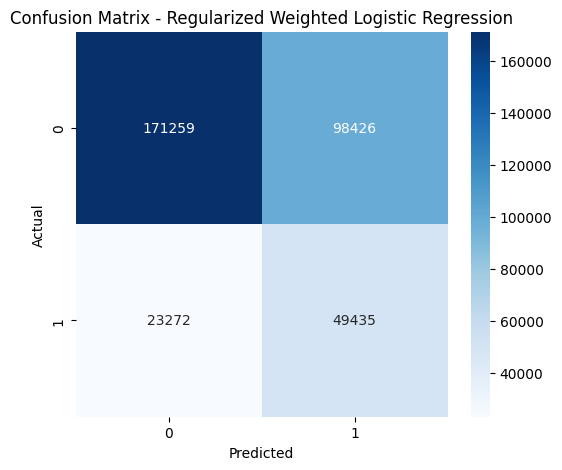

In [16]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix - Regularized Weighted Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [17]:
print(classification_report(y_test, best_logistic_preds))

              precision    recall  f1-score   support

           0       0.88      0.64      0.74    269685
           1       0.33      0.68      0.45     72707

    accuracy                           0.64    342392
   macro avg       0.61      0.66      0.59    342392
weighted avg       0.76      0.64      0.68    342392



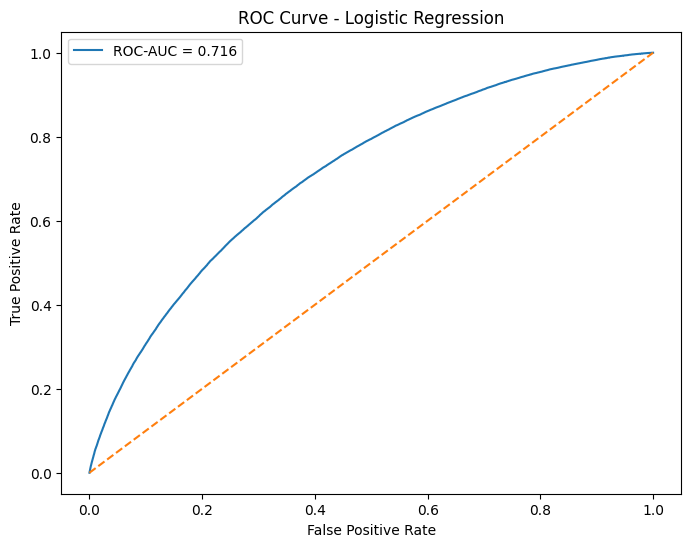

In [18]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, best_logistic_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc_score(y_test, best_logistic_probs):.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - Logistic Regression")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

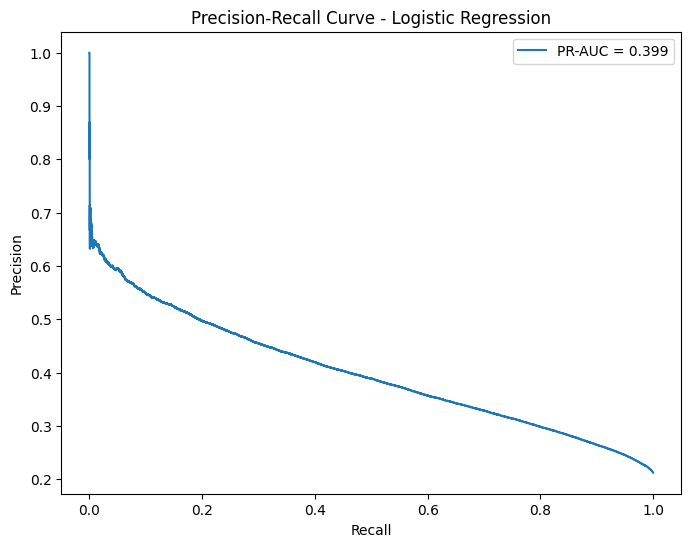

In [19]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(y_test, best_logistic_probs)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f"PR-AUC = {average_precision_score(y_test, best_logistic_probs):.3f}")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

In [20]:
fitted_preprocessor = regularized_logistic_model.named_steps["preprocessor"]
fitted_model = regularized_logistic_model.named_steps["model"]

encoded_cat_features = (
    fitted_preprocessor
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(categorical_features)
)

all_feature_names = numeric_features + encoded_cat_features.tolist()

coef_df = pd.DataFrame({
    "feature": all_feature_names,
    "coefficient": fitted_model.coef_[0]
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df.sort_values("abs_coefficient", ascending=False).head(30)

,feature,coefficient,abs_coefficient
81,purpose_educational,0.777839,0.777839
107,credit_history_band_Short Credit History,0.693201,0.693201
72,home_ownership_OTHER,0.638763,0.638763
34,sub_grade_A1,-0.554119,0.554119
1,funded_amnt,-0.482560,0.482560
5,grade_risk_numeric,0.395116,0.395116
89,purpose_small_business,0.355100,0.355100
27,grade_A,-0.345103,0.345103
38,sub_grade_A5,0.300932,0.300932
70,home_ownership_MORTGAGE,-0.272626,0.272626


In [21]:
coef_df.sort_values("abs_coefficient", ascending=False).to_csv(
    "../data/outputs/logistic_regression_coefficients.csv",
    index=False
)

## Logistic Regression Interpretation

Logistic regression provides an interpretable benchmark model for credit risk prediction. Positive coefficients increase the log-odds of default, while negative coefficients reduce the log-odds of default.

The most important variables should be reviewed from a business perspective to confirm that the model is learning reasonable borrower risk patterns rather than relying on leakage or unstable variables.

In [22]:
logistic_score_output = X_test.copy()
logistic_score_output["actual_default"] = y_test.values
logistic_score_output["predicted_pd_logistic"] = best_logistic_probs
logistic_score_output["predicted_default_050"] = best_logistic_preds

logistic_score_output.to_csv(
    "../data/outputs/logistic_score_output.csv",
    index=False
)

logistic_score_output.head()

,loan_amnt,funded_amnt,term_months,int_rate,installment,grade,sub_grade,grade_risk_numeric,emp_length_years,home_ownership,annual_inc,verification_status,purpose,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,application_type,mort_acc,pub_rec_bankruptcies,issue_year,issue_month,credit_history_months,loan_income_ratio,installment_income_ratio,high_dti_flag,high_revol_util_flag,recent_inquiry_flag,long_term_flag,income_band,dti_band,credit_history_band,actual_default,predicted_pd_logistic,predicted_default_050
1369478,10000.0,10000.0,36,10.49,324.98,B,B3,2,10.0,MORTGAGE,62000.0,Not Verified,debt_consolidation,9.50,0.0,0.0,16.0,1.0,8056.0,26.2,53.0,Individual,1.0,1.0,2016,10,289.0,0.161290,0.062899,0,0,0,0,Middle Income,Low DTI,Long Credit History,0,0.301951,0
319065,4000.0,4000.0,36,12.69,134.18,C,C2,3,10.0,MORTGAGE,102000.0,Not Verified,home_improvement,18.24,0.0,0.0,8.0,0.0,7132.0,52.4,10.0,Individual,2.0,0.0,2015,3,83.0,0.039216,0.015786,0,0,0,0,Upper Middle Income,Moderate DTI,Moderate Credit History,0,0.342051,0
1321575,22400.0,22400.0,60,18.99,580.95,D,D3,4,10.0,MORTGAGE,70000.0,Not Verified,credit_card,25.72,0.0,1.0,7.0,1.0,11386.0,40.4,22.0,Individual,3.0,1.0,2016,12,279.0,0.320000,0.099591,0,0,0,1,Middle Income,High DTI,Long Credit History,0,0.689206,1
900477,10000.0,10000.0,36,10.99,327.34,B,B2,2,0.0,RENT,70000.0,Not Verified,debt_consolidation,17.59,0.0,1.0,13.0,0.0,10130.0,39.2,17.0,Individual,0.0,0.0,2014,1,100.0,0.142857,0.056115,0,0,0,0,Middle Income,Moderate DTI,Established Credit History,0,0.315858,0
675610,5000.0,5000.0,36,9.17,159.40,B,B2,2,0.0,OWN,62000.0,Source Verified,debt_consolidation,15.18,0.0,0.0,6.0,0.0,5129.0,68.4,12.0,Individual,1.0,0.0,2016,1,101.0,0.080645,0.030852,0,0,0,0,Middle Income,Moderate DTI,Established Credit History,0,0.319157,0


# Logistic Modeling Summary

## Key Actions Completed

- Built a naive baseline model.
- Built standard logistic regression.
- Built class-weighted logistic regression.
- Built regularized weighted logistic regression.
- Compared models using ROC-AUC, PR-AUC, precision, recall, F1-score, and accuracy.
- Generated confusion matrix, ROC curve, and precision-recall curve.
- Extracted logistic regression coefficients for explainability.
- Saved model results and prediction outputs.

## Business Interpretation

Logistic regression is a useful benchmark model because it is interpretable and commonly used in credit risk contexts. However, the default threshold of 0.50 may not be optimal for business use. Future steps will test tree-based models and tune thresholds based on manual review capacity and default detection needs.

## Next Step

The next notebook will build tree-based machine learning models, including decision tree, random forest, and gradient boosting.